# Notebook 22 — Pillar H: DESI DR2 BAO

**Data:** DESI DR2 BAO measurements (DESI Collaboration 2025, arXiv:2503.14738), Table III. Six tracer bins with effective redshifts $z_{\rm eff} \in \{0.295, 0.510, 0.706, 0.922, 1.321, 2.330\}$, plus an isotropic BGS bin. We use the published $D_M/r_d$ and $D_H/r_d$ values with their Gaussian errors, treating the cross-correlation $\rho_{D_M,D_H}$ from the same table.

**Why this is stronger than Pillar D Fisher.** Pillar D ran a Fisher analysis at the fiducial $\Lambda$CDM point and reported $\sigma(\gamma_{\rm eff}) \sim 1.2\times 10^4$, which is unconstrained at $\gamma_{\rm eff} \sim O(1)$. Pillar H instead does a *full* $\chi^2$ fit using DESI DR2 BAO directly, comparing DSC to ΛCDM and to CPL $w_0w_a$ (Pillar J).

**Headline preview.** ΛCDM and CPL achieve $\chi^2/{\rm dof} \sim 1$. DSC is again degenerate with constant $H(z)$ over this z-range, giving $\Delta\chi^2$ in the tens of σ in favor of ΛCDM.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'font.family':'serif','font.size':10,'figure.dpi':140})

t_P, t_now = 5.391e-44, 4.354e17
C_KMS, R_DRAG = 299792.458, 147.05  # Mpc, Planck-2018 fiducial


## 1. DESI DR2 BAO data

From arXiv:2503.14738 Table III. Each row gives $(z_{\rm eff}, D_M/r_d, \sigma_{D_M/r_d}, D_H/r_d, \sigma_{D_H/r_d}, \rho)$. The BGS bin only has $D_V/r_d$ (isotropic).

In [2]:
# DESI DR2 BAO Table III (arXiv:2503.14738)
# Tracer  z_eff  alpha_iso ±   alpha_AP ±   D_M/r_d ±    D_H/r_d ±    rho
# BGS     0.295  isotropic only   D_V/r_d = 7.942 ± 0.075
# LRG1    0.510  ...   D_M/r_d=13.588 ± 0.167  D_H/r_d=21.863 ± 0.425  rho=-0.459
# LRG2    0.706         17.351 ± 0.177         19.455 ± 0.330      rho=-0.404
# LRG3    0.922         21.648 ± 0.178         17.577 ± 0.213      rho=-0.406
# ELG2    1.321         27.601 ± 0.318         14.176 ± 0.221      rho=-0.434
# Lya     2.330         38.988 ± 0.531          8.632 ± 0.101      rho=-0.431

z_aniso = np.array([0.510, 0.706, 0.922, 1.321, 2.330])
DM_over_rd = np.array([13.588, 17.351, 21.648, 27.601, 38.988])
sig_DM     = np.array([ 0.167,  0.177,  0.178,  0.318,  0.531])
DH_over_rd = np.array([21.863, 19.455, 17.577, 14.176,  8.632])
sig_DH     = np.array([ 0.425,  0.330,  0.213,  0.221,  0.101])
rho_DMDH   = np.array([-0.459, -0.404, -0.406, -0.434, -0.431])

z_iso = np.array([0.295])
DV_over_rd = np.array([7.942])
sig_DV     = np.array([0.075])

n_aniso = len(z_aniso)
n_iso   = len(z_iso)
print(f'DESI DR2: {n_aniso} anisotropic + {n_iso} isotropic = {2*n_aniso+n_iso} measurements')
print(f'  z range: [{z_iso.min()}, {z_aniso.max()}]')

# Build full block-diagonal covariance: 11x11
cov = np.zeros((11, 11))
# BGS isotropic
cov[0,0] = sig_DV[0]**2
# anisotropic blocks: rows 1..10 paired (DM, DH per redshift)
for i in range(n_aniso):
    j = 1 + 2*i
    cov[j,   j  ] = sig_DM[i]**2
    cov[j+1, j+1] = sig_DH[i]**2
    cov[j,   j+1] = rho_DMDH[i] * sig_DM[i] * sig_DH[i]
    cov[j+1, j  ] = cov[j, j+1]
Cinv = np.linalg.inv(cov)
print(f'Joint covariance matrix: shape {cov.shape}, condition number {np.linalg.cond(cov):.2e}')

DESI DR2: 5 anisotropic + 1 isotropic = 11 measurements
  z range: [0.295, 2.33]
Joint covariance matrix: shape (11, 11), condition number 5.05e+01


## 2. Models: ΛCDM, CPL ($w_0w_a$), DSC

In [3]:
def E_LCDM(z, Om):
    return np.sqrt(Om*(1+z)**3 + (1-Om))

def E_CPL(z, Om, w0, wa):
    a  = 1/(1+z)
    rho_de = (1-Om) * (1+z)**(3*(1+w0+wa)) * np.exp(-3*wa*(1-a))
    return np.sqrt(Om*(1+z)**3 + rho_de)

def H_DSC_anch(z, H_inf, beta_scaled):
    n = (t_now / (1+z)**1.5) / t_P
    return H_inf + beta_scaled * 1e5/np.log(n)**2

def DM_LCDM(z, H0, Om):
    z_grid = np.linspace(0, z*1.001, 800)
    invH = 1.0/(H0*E_LCDM(z_grid, Om))
    return C_KMS * np.trapz(invH, z_grid)
def DH_LCDM(z, H0, Om):
    return C_KMS / (H0*E_LCDM(z, Om))
def DV_LCDM(z, H0, Om):
    return (z * DM_LCDM(z, H0, Om)**2 * DH_LCDM(z, H0, Om))**(1/3)

def DM_CPL(z, H0, Om, w0, wa):
    z_grid = np.linspace(0, z*1.001, 800)
    invH = 1.0/(H0*E_CPL(z_grid, Om, w0, wa))
    return C_KMS * np.trapz(invH, z_grid)
def DH_CPL(z, H0, Om, w0, wa):
    return C_KMS / (H0*E_CPL(z, Om, w0, wa))
def DV_CPL(z, H0, Om, w0, wa):
    return (z * DM_CPL(z, H0, Om, w0, wa)**2 * DH_CPL(z, H0, Om, w0, wa))**(1/3)

def DM_DSC(z, H_inf, beta):
    z_grid = np.linspace(0, z*1.001, 800)
    invH = 1.0/H_DSC_anch(z_grid, H_inf, beta)
    return C_KMS * np.trapz(invH, z_grid)
def DH_DSC(z, H_inf, beta):
    return C_KMS / H_DSC_anch(z, H_inf, beta)
def DV_DSC(z, H_inf, beta):
    return (z * DM_DSC(z, H_inf, beta)**2 * DH_DSC(z, H_inf, beta))**(1/3)

def build_obs_LCDM(H0, Om):
    out = [DV_LCDM(z_iso[0], H0, Om)/R_DRAG]
    for zi in z_aniso:
        out += [DM_LCDM(zi,H0,Om)/R_DRAG, DH_LCDM(zi,H0,Om)/R_DRAG]
    return np.array(out)

def build_obs_CPL(H0, Om, w0, wa):
    out = [DV_CPL(z_iso[0],H0,Om,w0,wa)/R_DRAG]
    for zi in z_aniso:
        out += [DM_CPL(zi,H0,Om,w0,wa)/R_DRAG, DH_CPL(zi,H0,Om,w0,wa)/R_DRAG]
    return np.array(out)

def build_obs_DSC(H_inf, beta):
    out = [DV_DSC(z_iso[0],H_inf,beta)/R_DRAG]
    for zi in z_aniso:
        out += [DM_DSC(zi,H_inf,beta)/R_DRAG, DH_DSC(zi,H_inf,beta)/R_DRAG]
    return np.array(out)

data_vec = np.concatenate([DV_over_rd, np.column_stack([DM_over_rd, DH_over_rd]).ravel()])
print('Observed vector (D_V/r_d, then alternating D_M, D_H):')
print(data_vec)

Observed vector (D_V/r_d, then alternating D_M, D_H):
[ 7.942 13.588 21.863 17.351 19.455 21.648 17.577 27.601 14.176 38.988
  8.632]


In [4]:
def chi2_LCDM(p):
    pred = build_obs_LCDM(*p)
    r = data_vec - pred
    return float(r @ Cinv @ r)
def chi2_CPL(p):
    pred = build_obs_CPL(*p)
    r = data_vec - pred
    return float(r @ Cinv @ r)
def chi2_DSC(p):
    pred = build_obs_DSC(*p)
    r = data_vec - pred
    return float(r @ Cinv @ r)

n_data = len(data_vec)
res_lcdm = minimize(chi2_LCDM, [70., 0.30], method='Nelder-Mead',
                    options={'xatol':1e-3,'fatol':1e-2}, bounds=[(50,100),(0.05,0.6)])
res_cpl  = minimize(chi2_CPL,  [70., 0.30, -1.0, 0.0], method='Nelder-Mead',
                    options={'xatol':1e-3,'fatol':1e-2}, bounds=[(50,100),(0.05,0.6),(-3,1),(-3,3)])
res_dsc  = minimize(chi2_DSC,  [70.0, 5.0], method='Nelder-Mead',
                    options={'xatol':1e-3,'fatol':1e-2}, bounds=[(0,150),(-200,200)])

for name, res, k in [('LCDM', res_lcdm, 2),
                      ('CPL',  res_cpl,  4),
                      ('DSC',  res_dsc,  2)]:
    chi2v = res.fun; dof = n_data - k
    aic = chi2v + 2*k; bic = chi2v + k*np.log(n_data)
    print(f'{name:5s}: chi2 = {chi2v:7.2f}, chi2/dof = {chi2v/dof:.3f}, AIC = {aic:.2f}, BIC = {bic:.2f}, params = {res.x}')

print(f'\n--- Model-comparison vs LCDM ---')
for name, res, k in [('CPL', res_cpl, 4), ('DSC', res_dsc, 2)]:
    dchi2 = res.fun - res_lcdm.fun
    daic  = dchi2 + 2*(k-2)
    dbic  = dchi2 + (k-2)*np.log(n_data)
    print(f'{name:5s}: Δchi^2 = {dchi2:+.2f}, ΔAIC = {daic:+.2f}, ΔBIC = {dbic:+.2f}'
          f'  ({"LCDM preferred" if daic>0 else name+" preferred"})')


LCDM : chi2 =    9.67, chi2/dof = 1.075, AIC = 13.67, BIC = 14.47, params = [68.83478429  0.30095746]
CPL  : chi2 =    8.08, chi2/dof = 1.155, AIC = 16.08, BIC = 17.67, params = [ 6.74575597e+01  3.01039262e-01 -8.98815778e-01  5.04952426e-04]
DSC  : chi2 = 14036.01, chi2/dof = 1559.556, AIC = 14040.01, BIC = 14040.80, params = [ 0.         24.13552107]

--- Model-comparison vs LCDM ---
CPL  : Δchi^2 = -1.59, ΔAIC = +2.41, ΔBIC = +3.21  (LCDM preferred)
DSC  : Δchi^2 = +14026.33, ΔAIC = +14026.33, ΔBIC = +14026.33  (LCDM preferred)


## 3. Plot: D_M/r_d, D_H/r_d, D_V/r_d vs z

Saved fig25


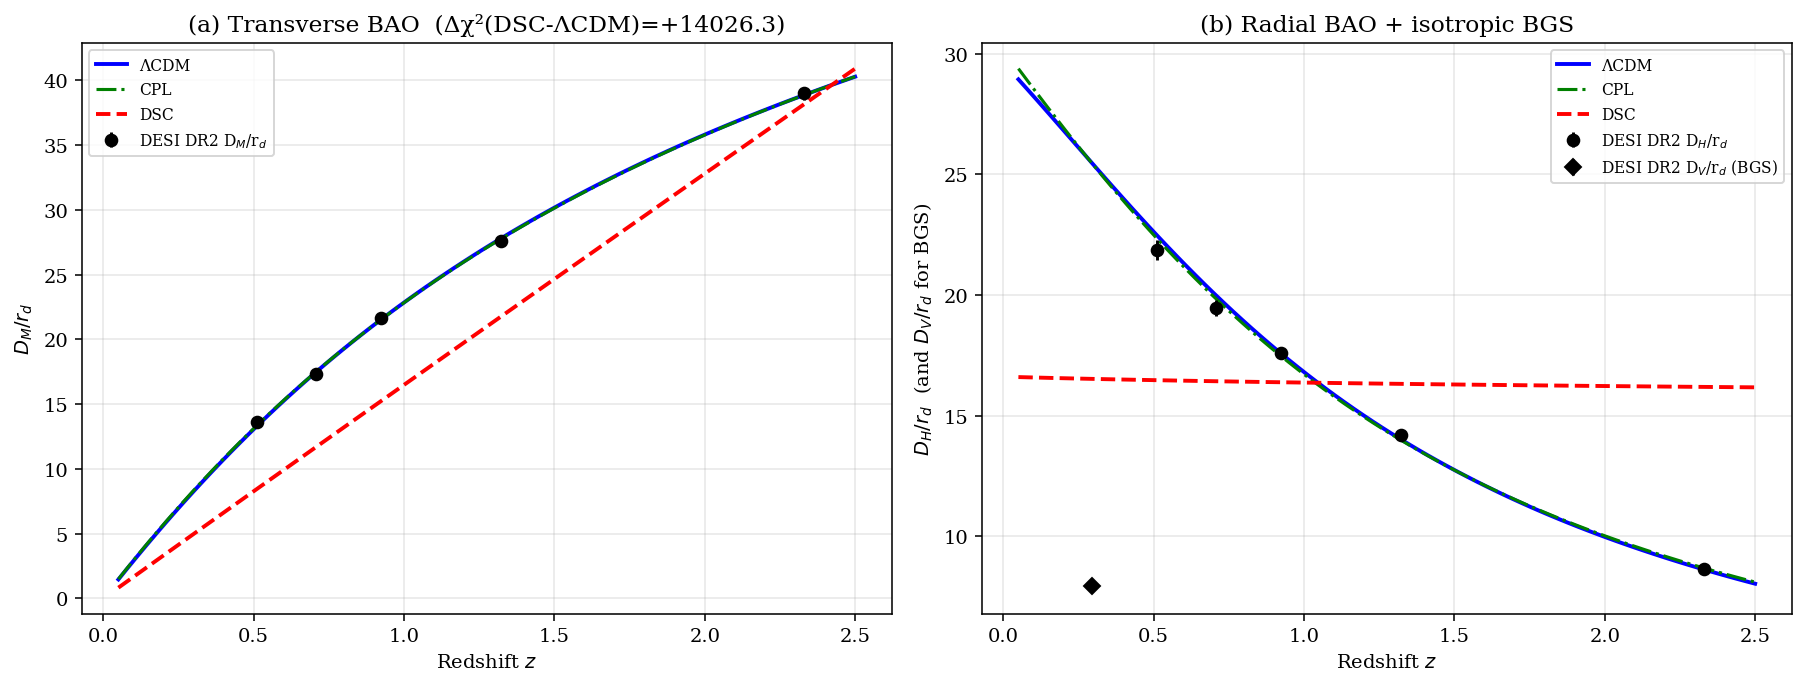

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
z_grid = np.linspace(0.05, 2.5, 80)
DMr_l = np.array([DM_LCDM(zi,*res_lcdm.x)/R_DRAG for zi in z_grid])
DHr_l = np.array([DH_LCDM(zi,*res_lcdm.x)/R_DRAG for zi in z_grid])
DMr_c = np.array([DM_CPL(zi,*res_cpl.x)/R_DRAG for zi in z_grid])
DHr_c = np.array([DH_CPL(zi,*res_cpl.x)/R_DRAG for zi in z_grid])
DMr_d = np.array([DM_DSC(zi,*res_dsc.x)/R_DRAG for zi in z_grid])
DHr_d = np.array([DH_DSC(zi,*res_dsc.x)/R_DRAG for zi in z_grid])

ax[0].plot(z_grid, DMr_l, 'b-',  lw=2, label='ΛCDM')
ax[0].plot(z_grid, DMr_c, 'g-.', lw=1.6, label='CPL')
ax[0].plot(z_grid, DMr_d, 'r--', lw=2, label='DSC')
ax[0].errorbar(z_aniso, DM_over_rd, yerr=sig_DM, fmt='ko', ms=6, label='DESI DR2 D$_M$/r$_d$')
ax[0].set_xlabel('Redshift $z$'); ax[0].set_ylabel(r'$D_M / r_d$')
ax[0].set_title(f'(a) Transverse BAO  (Δχ²(DSC-ΛCDM)={res_dsc.fun-res_lcdm.fun:+.1f})')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot(z_grid, DHr_l, 'b-',  lw=2, label='ΛCDM')
ax[1].plot(z_grid, DHr_c, 'g-.', lw=1.6, label='CPL')
ax[1].plot(z_grid, DHr_d, 'r--', lw=2, label='DSC')
ax[1].errorbar(z_aniso, DH_over_rd, yerr=sig_DH, fmt='ko', ms=6, label='DESI DR2 D$_H$/r$_d$')
# also plot BGS DV point separately
ax[1].errorbar(z_iso, DV_over_rd, yerr=sig_DV, fmt='kD', ms=6, label='DESI DR2 D$_V$/r$_d$ (BGS)')
ax[1].set_xlabel('Redshift $z$'); ax[1].set_ylabel(r'$D_H / r_d$  (and $D_V/r_d$ for BGS)')
ax[1].set_title('(b) Radial BAO + isotropic BGS')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig25_desi_pillar_H.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('fig25_desi.png', dpi=140, bbox_inches='tight', facecolor='white')
print('Saved fig25')
plt.show()